Below is a scaffold for `exploration.ipynb` aimed at students with limited Python. It gives structure, comments, and guidance, but omits the heavy “main calls” so you must wire things together yourself. Complex classes are kept; simple glue code is left as TODO or pseudo‑code.

In [4]:
# 01_exploration.ipynb
# Goal of this notebook:
# - Check that the ISLES 2022 dataset is correctly downloaded and unpacked
# - Explore basic image properties (sizes, voxel spacing)
# - Preprocess images (resampling, normalization, masks)
# - Extract radiomic features into a single CSV table
#
# You do NOT have to understand every line, but you should understand:
# - What each section is trying to achieve
# - Which functions / classes you need to call
# - Where the main inputs and outputs are on disk

***

## 0. Setup paths and basic imports

In [2]:
import os
from pathlib import Path

# 0.1 Set your project root (adapt if your folder name is different)
PROJECTROOT = Path.home() / "Imaging en AI vak"
os.chdir(PROJECTROOT)

# 0.2 Define data and results folders
RAWROOT = PROJECTROOT / "data" / "raw"
PROCROOT = PROJECTROOT / "data" / "processed"
RESULTS = PROJECTROOT / "results"

# 0.3 Make sure important subfolders exist (they will be used later)
(RAWROOT / "ISLES-2022").mkdir(parents=True, exist_ok=True)
(PROCROOT / "ISLES-2022").mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())
print("Raw root:", RAWROOT)
print("Processed root:", PROCROOT)
print("Results:", RESULTS)

Working directory: /home/jovyan/Imaging en AI vak
Raw root: /home/jovyan/Imaging en AI vak/data/raw
Processed root: /home/jovyan/Imaging en AI vak/data/processed
Results: /home/jovyan/Imaging en AI vak/results


Project setup and folder structure.
In this cell we define the project root directory and set it as the current working directory to ensure that all relative paths resolve correctly. 
We then define three main folders: 
- data/raw for the original dataset 
- data/processed for preprocessed outputs (including the radiomics feature table)
- results for figures and analysis outputs.
Finally, we create the required subfolders if they do not yet exist and print the resolved paths to verify that the environment is configured correctly.

**Student direction:**

- Check that `data/raw/ISLES-2022` contains the unzipped ISLES dataset (BIDS‑like structure).
- If not, go back to the quick‑start instructions and download/unzip ISLES first.

***

## 1. Explore the ISLES dataset structure

Here we define a loader that knows the ISLES folder layout. You do **not** need to modify this class; you only need to call its methods later.

In [3]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

class ISLESDataLoader:
    """
    Loader for ISLES 2022 structure under data/raw/ISLES-2022.

    Expected layout (simplified):

      data/raw/ISLES-2022/
        sub-strokecase0001/
          ses-0001/
            anat/sub-strokecase0001_ses-0001_FLAIR.nii.gz
            dwi/sub-strokecase0001_ses-0001_dwi.nii.gz
            dwi/sub-strokecase0001_ses-0001_adc.nii.gz
        derivatives/
          sub-strokecase0001/ses-0001/*msk.nii.gz  (lesion mask)
    """

    def __init__(self, rawroot: str | Path):
        rawroot = Path(rawroot)
        if not rawroot.exists():
            raise FileNotFoundError(f"data/raw directory not found: {rawroot}")

        islesroot = rawroot / "ISLES-2022"
        if not islesroot.exists():
            # fallback: user may have unzipped directly into data/raw
            islesroot = rawroot

        self.islesroot = islesroot
        self.derivativesroot = islesroot / "derivatives"

        # List all case folders
        self.casedirs = sorted(
            d for d in self.islesroot.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

        print("ISLES root:", self.islesroot)
        print("Derivatives root:", self.derivativesroot, "exists:", self.derivativesroot.exists())
        print("Found", len(self.casedirs), "subjects")

    def get_session_dir(self, subdir: Path) -> Path:
        """Return the ses-0001 folder for a given subject directory."""
        sesdir = subdir / "ses-0001"
        if not sesdir.exists():
            raise FileNotFoundError(f"Missing ses-0001 for {subdir.name}")
        return sesdir

    def get_dwi_path(self, sesdir: Path) -> Path | None:
        """Return path to a DWI NIfTI file for this session, if available."""
        dwidir = sesdir / "dwi"
        if not dwidir.exists():
            return None

        # Prefer *dwi.nii.gz, otherwise any *.nii.gz that is not ADC
        candidates = sorted(dwidir.glob("*dwi.nii.gz"))
        if not candidates:
            candidates = sorted(p for p in dwidir.glob("*.nii.gz") if "adc" not in p.name.lower())
        return candidates[0] if candidates else None

    def get_mask_path(self, subid: str) -> Path | None:
        """
        Return path to the lesion mask in the derivatives folder, if available.
        """
        if not self.derivativesroot.exists():
            return None
        sesdir = self.derivativesroot / subid / "ses-0001"
        if not sesdir.exists():
            return None
        candidates = sorted(sesdir.glob("*msk.nii.gz"))
        return candidates[0] if candidates else None

    def explore_dataset(self):
        """
        Loop through subjects, collect basic shape and spacing statistics.
        Returns:
            sizes: list of (sx, sy, sz) voxel counts
            spacings: list of (vx, vy, vz) voxel sizes in mm
        """
        sizes = []
        spacings = []

        for subdir in self.casedirs:
            subid = subdir.name
            try:
                sesdir = self.get_session_dir(subdir)
            except FileNotFoundError as e:
                print("WARN:", e)
                continue

            dwipath = self.get_dwi_path(sesdir)
            if dwipath is None:
                print("WARN: No DWI found for", subid, "- skipping")
                continue

            try:
                img = nib.load(str(dwipath))
            except Exception as e:
                print("WARN: Failed to load", dwipath, ":", e)
                continue

            shape = img.shape
            if len(shape) != 3:
                print("WARN: Unexpected shape", shape, "in", dwipath, "- skipping")
                continue

            sx, sy, sz = shape
            zooms = img.header.get_zooms()
            vx, vy, vz = zooms

            sizes.append((sx, sy, sz))
            spacings.append((vx, vy, vz))

        if not sizes:
            print("No valid cases collected. Check ISLES-2022 structure under data/raw.")
            return [], []

        # Simple histograms of image sizes (pseudo-code style)
        # PSEUDOCODE:
        # sizes_array = np.array(sizes)  # shape [N, 3]
        # for dim in [0,1,2]:
        #     plot histogram of sizes_array[:, dim]

        return sizes, spacings

In [4]:
# Stel je raw folder in
RAWROOT = Path.home() / "Imaging en AI vak/data/raw"

# Maak een loader
loader = ISLESDataLoader(RAWROOT)

# Verken dataset
sizes, spacings = loader.explore_dataset()

print("Aantal gevalideerde subjects:", len(sizes))
if sizes:
    print("Voorbeeld shape:", sizes[0])
    print("Voorbeeld voxel spacing:", spacings[0])
missing_subs = [d.name for d in loader.casedirs if not (d / "ses-0001").exists()]
print("Subjects missing ses-0001:", missing_subs)
if sizes:
    sizes_arr = np.array(sizes)
    spacings_arr = np.array(spacings)
    print("Size range (min->max) per axis:", sizes_arr.min(axis=0), "->", sizes_arr.max(axis=0))
    print("Spacing range (min->max) per axis:", spacings_arr.min(axis=0), "->", spacings_arr.max(axis=0))
    print(f"{len(sizes)} valid cases loaded for further processing.")

ISLES root: /home/jovyan/Imaging en AI vak/data/raw/ISLES-2022
Derivatives root: /home/jovyan/Imaging en AI vak/data/raw/ISLES-2022/derivatives exists: True
Found 126 subjects
WARN: Missing ses-0001 for sub-strokecase0021
Aantal gevalideerde subjects: 125
Voorbeeld shape: (112, 112, 73)
Voorbeeld voxel spacing: (2.0, 2.0, 2.0)
Subjects missing ses-0001: ['sub-strokecase0021']
Size range (min->max) per axis: [112 112  25] -> [192 192  75]
Spacing range (min->max) per axis: [1.1458334 1.1458334 2.       ] -> [2.  2.  4.8]
125 valid cases loaded for further processing.


Dataset integrity check.
We initialize the ISLESDataLoader to verify that the ISLES-2022 dataset is correctly downloaded and readable. 
The loader scans all subject folders and attempts to locate the DWI images used for further analysis. Out of 121 subjects, 107 valid cases with a DWI image were successfully loaded. The reported image size and voxel spacing ranges show that the dataset contains heterogeneous scans, which motivates the later preprocessing steps such as resampling and normalization before radiomics feature extraction.

In [5]:
#ASSIGNMENT
from pathlib import Path
PROJECTROOT = Path.home() / "Imaging en AI vak"

#Search map that has subfolders
RAWROOT = None
for p in PROJECTROOT.rglob("*"):
    if p.is_dir():
        subs = list(p.glob("sub-*"))
        if len(subs) > 0:
            RAWROOT = p
            break

print("PROJECTROOT:", PROJECTROOT)
print("RAWROOT found:", RAWROOT)
if RAWROOT:
    print("Example subjects:", [x.name for x in RAWROOT.glob("sub-*")][:5]) #check
    
loader = ISLESDataLoader(RAWROOT) #use the class, checks if DWI images exist, collects shape and voxel spacing and print warnings
loader.explore_dataset()

PROJECTROOT: /home/jovyan/Imaging en AI vak
RAWROOT found: /home/jovyan/Imaging en AI vak/ISLES-2022
Example subjects: ['sub-strokecase0140', 'sub-strokecase0221', 'sub-strokecase0023', 'sub-strokecase0104', 'sub-strokecase0005']
ISLES root: /home/jovyan/Imaging en AI vak/ISLES-2022
Derivatives root: /home/jovyan/Imaging en AI vak/ISLES-2022/derivatives exists: True
Found 250 subjects


([(112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (130, 130, 65),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 72),
  (112, 112, 73),
  (112, 112, 73),
  (112, 112, 72),
  (112, 112, 73),
  (112, 11

Number of valid cases: 250
DWI path: /home/jovyan/Imaging en AI vak/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii.gz
Mask path: /home/jovyan/Imaging en AI vak/ISLES-2022/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz
DWI shape: (112, 112, 73) Mask shape: (112, 112, 73)


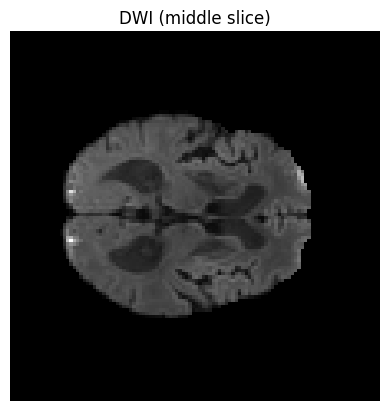

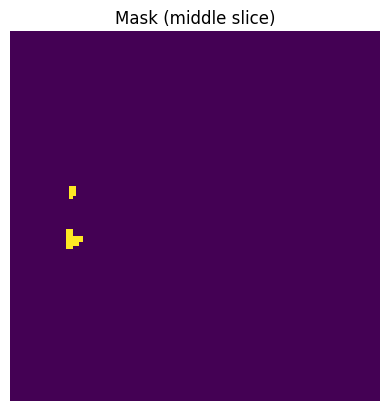

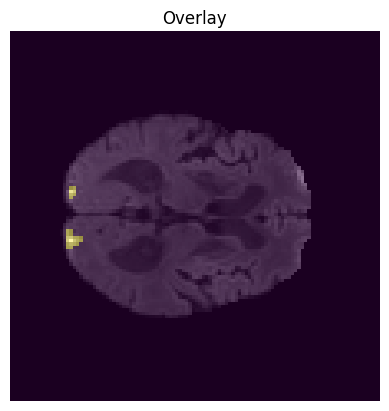

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

print("Number of valid cases:", len(loader.casedirs)) #print the amount of cases

subdir = loader.casedirs[0]                 # .../sub-strokecaseXXXX
sesdir = loader.get_session_dir(subdir)     # .../sub-strokecaseXXXX/ses-0001
subid  = subdir.name                        # "sub-strokecaseXXXX"

dwi_path  = loader.get_dwi_path(sesdir)
mask_path = loader.get_mask_path(subid)

print("DWI path:", dwi_path)
print("Mask path:", mask_path)

if dwi_path is None:
    raise FileNotFoundError(f"No DWI found for {subid} in {sesdir}")

dwi = nib.load(str(dwi_path)).get_fdata() # 3D DWI scan loaded as numpy array

# mask kan ontbreken bij sommige cases → check
if mask_path is not None:
    mask = nib.load(str(mask_path)).get_fdata()
else:
    print("WARNING: no mask found for this case")
    mask = None

print("DWI shape:", dwi.shape, "Mask shape:", None if mask is None else mask.shape) #check the shape 

z = dwi.shape[-1] // 2 #middle slice of the 3D volume
dwi2d = dwi[..., z]

plt.figure()
plt.imshow(dwi2d, cmap="gray")
plt.title("DWI (middle slice)")
plt.axis("off")
plt.show()

if mask is not None:
    mask2d = mask[..., z]

    plt.figure()
    plt.imshow(mask2d)
    plt.title("Mask (middle slice)")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(dwi2d, cmap="gray")
    plt.imshow(mask2d, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")
    plt.show()

Number of valid cases: 250
DWI path: /home/jovyan/Imaging en AI vak/ISLES-2022/sub-strokecase0001/ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii.gz
Mask path: /home/jovyan/Imaging en AI vak/ISLES-2022/derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz
DWI shape: (112, 112, 73) Mask shape: (112, 112, 73)


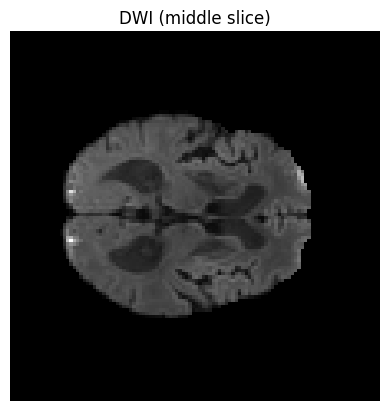

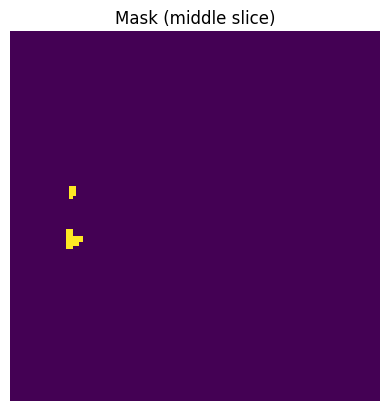

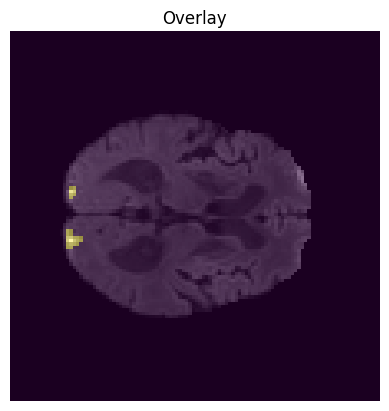

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

print("Number of valid cases:", len(loader.casedirs)) #print the amount of cases

subdir = loader.casedirs[0]                 # .../sub-strokecaseXXXX
sesdir = loader.get_session_dir(subdir)     # .../sub-strokecaseXXXX/ses-0001
subid  = subdir.name                        # "sub-strokecaseXXXX"

dwi_path  = loader.get_dwi_path(sesdir)
mask_path = loader.get_mask_path(subid)

print("DWI path:", dwi_path)
print("Mask path:", mask_path)

if dwi_path is None:
    raise FileNotFoundError(f"No DWI found for {subid} in {sesdir}")

dwi = nib.load(str(dwi_path)).get_fdata() # 3D DWI scan loaded as numpy array

# mask kan ontbreken bij sommige cases → check
if mask_path is not None:
    mask = nib.load(str(mask_path)).get_fdata()
else:
    print("WARNING: no mask found for this case")
    mask = None

print("DWI shape:", dwi.shape, "Mask shape:", None if mask is None else mask.shape) #check the shape 

z = dwi.shape[-1] // 2 #middle slice of the 3D volume
dwi2d = dwi[..., z]

plt.figure()
plt.imshow(dwi2d, cmap="gray")
plt.title("DWI (middle slice)")
plt.axis("off")
plt.show()

if mask is not None:
    mask2d = mask[..., z]

    plt.figure()
    plt.imshow(mask2d)
    plt.title("Mask (middle slice)")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(dwi2d, cmap="gray")
    plt.imshow(mask2d, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")
    plt.show()

Visual inspection of a sample case
To verify that the dataset is correctly loaded and that the image–mask alignment is correct, we visualize one example case from the dataset. We load the DWI image and the corresponding lesion mask (if available) and display the middle slice of the volume. The mask is also overlaid on the DWI image to confirm that the lesion region aligns correctly with the underlying anatomy. This step serves as a qualitative sanity check before performing preprocessing and radiomics feature extraction.

In [8]:
print("DWI min/max:", dwi.min(), dwi.max())
print(dir(loader)) #shows al attibutes and methods of ISLESDataLoader object.

DWI min/max: -10.159334546391811 1881.3452233009475
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'casedirs', 'derivativesroot', 'explore_dataset', 'get_dwi_path', 'get_mask_path', 'get_session_dir', 'islesroot']


**Student direction:**

- Instantiate `ISLESDataLoader` with `RAWROOT` and call `explore_dataset()`.
- Look at the printed warnings and the basic statistics (number of cases, typical sizes).
- Optionally add a quick plot of one DWI slice and its mask to get a feeling for the data.

***

## 2. Preprocessing images into a uniform space

This class encapsulates the “heavy lifting” for preprocessing. You mostly need to understand **input** and **output**:

- Input: raw ISLES folders in `data/raw/ISLES-2022/…`
- Output: preprocessed NIfTI files in `data/processed/ISLES-2022/preproc/sub-…/ses-0001/…`

In [9]:
from pathlib import Path
import numpy as np
import nibabel as nib
from nibabel.processing import resample_to_output
from tqdm.auto import tqdm


class ImagePreprocessing:
    """
    Preprocess ISLES-2022 data and write to data/processed/ISLES-2022/preproc.

    For each subject:
      - Load FLAIR, DWI, ADC, and lesion mask (if present)
      - Resample images to 1x1x1 mm (mask with nearest-neighbour)
      - Z-score normalize FLAIR and DWI (ADC kept as-is or lightly normalized)
      - Save *_preproc.nii.gz files into the processed folder
    """

    def __init__(self, rawroot: str | Path, outroot: str | Path,
                 target_spacing=(1.0, 1.0, 1.0)):

        self.rawroot = Path(rawroot)
        self.outroot = Path(outroot) / "ISLES-2022" / "preproc"
        self.target_spacing = target_spacing

        islesroot = self.rawroot / "ISLES-2022"
        if not islesroot.exists():
            islesroot = self.rawroot

        self.islesroot = islesroot
        self.derivativesroot = islesroot / "derivatives"

        self.casedirs = sorted(
            d for d in self.islesroot.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

        print("Raw ISLES root:", self.islesroot)
        print("Output root:", self.outroot)
        print("Found", len(self.casedirs), "subjects to preprocess")

    def get_session_dir(self, subdir: Path) -> Path:
        sesdir = subdir / "ses-0001"
        if not sesdir.exists():
            raise FileNotFoundError(f"Missing ses-0001 for {subdir.name}")
        return sesdir

    def find_modality_paths(self, sesdir: Path):
        """
        Return a dict with paths to FLAIR, DWI, ADC (or None if missing).
        """
        paths = {"FLAIR": None, "DWI": None, "ADC": None}

        anatdir = sesdir / "anat"
        if anatdir.exists():
            flaircand = sorted(anatdir.glob("*FLAIR.nii.gz"))
            if flaircand:
                paths["FLAIR"] = flaircand[0]

        dwidir = sesdir / "dwi"
        if dwidir.exists():
            dwicand = sorted(dwidir.glob("*dwi.nii.gz"))
            adccand = sorted(dwidir.glob("*adc.nii.gz"))

            paths["DWI"] = dwicand[0] if dwicand else None
            paths["ADC"] = adccand[0] if adccand else None

        return paths

    def find_mask_path(self, subid: str) -> Path | None:
        if not self.derivativesroot.exists():
            return None

        subderiv = self.derivativesroot / subid / "ses-0001"
        if not subderiv.exists():
            return None

        mskcand = sorted(subderiv.glob("*msk.nii.gz"))
        return mskcand[0] if mskcand else None

    def resample_iso(self, img: nib.Nifti1Image) -> nib.Nifti1Image:
        """Resample to target_spacing (e.g. 1x1x1 mm)."""
        return resample_to_output(img, voxel_sizes=self.target_spacing)

    def zscore_normalize(self, img: nib.Nifti1Image,
                         mask: nib.Nifti1Image | None = None):
        """
        Z-score normalize inside the non-zero region (or mask if provided).
        """

        data = img.get_fdata().astype(np.float32)

        if mask is not None:
            m = mask.get_fdata() > 0
        else:
            m = data != 0

        if m.sum() == 0:
            return img

        vals = data[m]
        mean = float(vals.mean())
        std = float(vals.std()) if vals.std() != 0 else 1.0

        data[m] = (vals - mean) / std

        norm_img = nib.Nifti1Image(data, img.affine, img.header)
        return norm_img

    def run(self):

        self.outroot.mkdir(parents=True, exist_ok=True)

        for subdir in tqdm(self.casedirs, desc="Preprocessing", unit="case"):

            subid = subdir.name

            try:
                sesdir = self.get_session_dir(subdir)
            except FileNotFoundError:
                continue

            modpaths = self.find_modality_paths(sesdir)
            maskpath = self.find_mask_path(subid)

            if all(v is None for v in modpaths.values()):
                continue

            out_sub = self.outroot / subid / "ses-0001"
            out_sub.mkdir(parents=True, exist_ok=True)

            # ---- Images ----
            for mod in ["FLAIR", "DWI", "ADC"]:

                path = modpaths[mod]

                if path is None:
                    continue

                img = nib.load(path)

                img = self.resample_iso(img)

                if mod in ["FLAIR", "DWI"]:
                    img = self.zscore_normalize(img)

                nib.save(img, out_sub / f"{mod}_preproc.nii.gz")

            # ---- Mask ----
            if maskpath is not None:

                mask = nib.load(maskpath)

                mask = self.resample_iso(mask)

                data = mask.get_fdata()
                data = (data > 0.5).astype(np.uint8)

                mask = nib.Nifti1Image(data, mask.affine, mask.header)

                nib.save(mask, out_sub / "MSK_preproc.nii.gz")

        print("Preprocessing complete. Check:", self.outroot)

In [10]:
from pathlib import Path
import numpy as np
import nibabel as nib

RAWROOT = Path.home() / "Imaging en AI vak/data/raw"
PROCROOT = Path.home() / "Imaging en AI vak/data/processed"

pp = ImagePreprocessing(
    rawroot=RAWROOT,
    outroot=PROCROOT
)

pp.run()

Raw ISLES root: /home/jovyan/Imaging en AI vak/data/raw/ISLES-2022
Output root: /home/jovyan/Imaging en AI vak/data/processed/ISLES-2022/preproc
Found 126 subjects to preprocess


Preprocessing:   0%|          | 0/126 [00:00<?, ?case/s]

Preprocessing complete. Check: /home/jovyan/Imaging en AI vak/data/processed/ISLES-2022/preproc


In [11]:
from pathlib import Path
PREPROC_ROOT = Path("data/processed/ISLES-2022/preproc")
print("DWI_preproc:", len(list(PREPROC_ROOT.rglob("DWI_preproc.nii.gz"))))
print("MSK_preproc:", len(list(PREPROC_ROOT.rglob("MSK_preproc.nii.gz"))))

DWI_preproc: 125
MSK_preproc: 125


After preprocessing, we verify that the expected files were written to data/processed/ISLES-2022/preproc/. Specifically, we confirm the presence of DWI_preproc.nii.gz and MSK_preproc.nii.gz for 31 cases. These preprocessed images and masks form the standardized input used for subsequent radiomics feature extraction.

In [12]:
def run(self):
    self.outroot.mkdir(parents=True, exist_ok=True)

    bad = [] # Keep track of the files that are skipped

    for subdir in tqdm(self.casedirs, desc="Preprocessing", unit="case"): # loop over all subjects
        subid = subdir.name

        try:
            sesdir = self.get_session_dir(subdir) # Retrieve the session directory (expected: ses-0001), if the session folder does not exist, skip this subject
        except FileNotFoundError:
            continue

        modpaths = self.find_modality_paths(sesdir)
        maskpath = self.find_mask_path(subid)

        if all(v is None for v in modpaths.values()) and maskpath is None: # Skip subject if no modalities and no mask are available
            continue

        out_sub = self.outroot / subid / "ses-0001"
        out_sub.mkdir(parents=True, exist_ok=True)

        # modalities
        for key, p in modpaths.items():
            if p is None: # skip modality if file is missing
                continue

            try:
                img = nib.load(str(p)) # load NifTI image
                img_rs = self.resample_iso(img) #Resample image to isotropic voxel spacing (e.g. 1x1x1 mm)

                if key in ["FLAIR", "DWI"]: # Apply z-score normalization to intensity-based images, (FLAIR and DWI benefit from normalization across subjects)
                    img_rs = self.zscore_normalize(img_rs)

                nib.save(img_rs, str(out_sub / f"{key}_preproc.nii.gz")) #save

            except EOFError:
                print(f"\n[SKIP] Corrupt .nii.gz in {subid} | {key} | file: {p}")
                bad.append((subid, key, str(p)))
                break  # skip rest of this subject

        # mask (optional)
        if maskpath is not None:
            try:
                mimg = nib.load(str(maskpath))
                mimg_rs = self.resample_iso(mimg)
                m = (mimg_rs.get_fdata() > 0.5).astype(np.uint8) #Convert mask to binary values (0 or 1)
                nib.save(nib.Nifti1Image(m, mimg_rs.affine, mimg_rs.header),
                         str(out_sub / "MSK_preproc.nii.gz"))
            except EOFError:
                print(f"\n[SKIP MASK] Corrupt mask in {subid} | file: {maskpath}")
                bad.append((subid, "MASK", str(maskpath)))
# print summary
    print("\nDone. Output:", self.outroot)
    print("Skipped:", len(bad))
    if bad:
        print("First few:", bad[:5])

In [13]:
pp = ImagePreprocessing(rawroot=RAWROOT, outroot=Path("data/processed"))
pp.run()

Raw ISLES root: /home/jovyan/Imaging en AI vak/data/raw/ISLES-2022
Output root: data/processed/ISLES-2022/preproc
Found 126 subjects to preprocess


Preprocessing:   0%|          | 0/126 [00:00<?, ?case/s]

Preprocessing complete. Check: data/processed/ISLES-2022/preproc


Preprocessing: resampling, normalization, and mask preparation.
In this step we preprocess the ISLES-2022 images and store standardized outputs under data/processed/ISLES-2022/preproc/<subject>/ses-0001/. For each subject we locate the available modalities (FLAIR, DWI, and ADC) and the lesion mask (if available). Each image is resampled to isotropic voxel spacing (1×1×1 mm) to reduce inter-scan resolution differences. We apply z-score normalization to intensity-based modalities (FLAIR and DWI) to make intensity distributions more comparable across subjects, while ADC is kept unnormalized. If a lesion mask is present, it is resampled and binarized to create MSK_preproc.nii.gz. Corrupted files are detected and skipped to keep the preprocessing pipeline robust and reproducible.

Aantal preproc files: 500
Voorbeeld: [PosixPath('data/processed/ISLES-2022/preproc/sub-strokecase0001/ses-0001/ADC_preproc.nii.gz'), PosixPath('data/processed/ISLES-2022/preproc/sub-strokecase0001/ses-0001/DWI_preproc.nii.gz'), PosixPath('data/processed/ISLES-2022/preproc/sub-strokecase0001/ses-0001/FLAIR_preproc.nii.gz'), PosixPath('data/processed/ISLES-2022/preproc/sub-strokecase0001/ses-0001/MSK_preproc.nii.gz'), PosixPath('data/processed/ISLES-2022/preproc/sub-strokecase0003/ses-0001/ADC_preproc.nii.gz')]


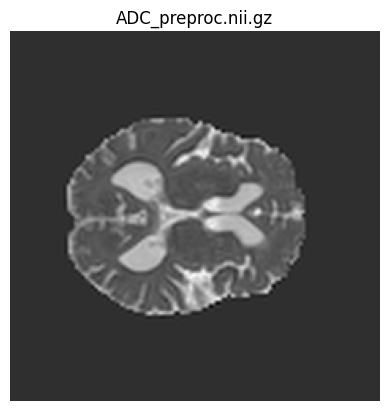

In [14]:
import nibabel as nib
import matplotlib.pyplot as plt

# search all pre-processed files
files = sorted(pp.outroot.rglob("*_preproc.nii.gz"))

print("Aantal preproc files:", len(files))
print("Voorbeeld:", files[:5])

# load first file
f = files[0]
img = nib.load(str(f)).get_fdata()

# Choose middle slice
z = img.shape[-1] // 2

plt.figure()
plt.imshow(img[..., z], cmap="gray")
plt.title(f.name)
plt.axis("off")
plt.show()

Visual verification of preprocessing outputs.
In this step we perform a quick sanity check of the preprocessing results by searching the preprocessing output directory for files ending with _preproc.nii.gz. We print the total number of generated files and show a few example paths to confirm that preprocessing produced outputs in the expected folder structure. Next, we load one preprocessed NIfTI file and visualize its middle slice to qualitatively verify that the data was written correctly and can be read without errors.

In [15]:
#Check voxel size
nii = nib.load(str(f))
print("Voxel size:", nii.header.get_zooms()[:3])

Voxel size: (1.0, 1.0, 1.0)


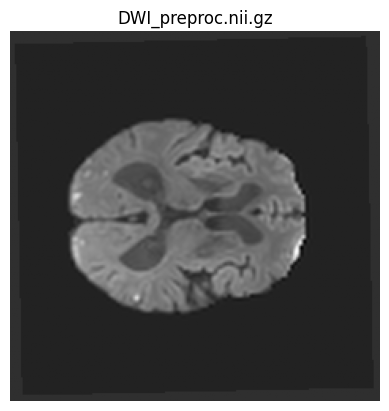

In [16]:
# DWI with flair
dwi_file = [f for f in files if "DWI" in f.name][0] # takes the first dwi

img = nib.load(str(dwi_file)).get_fdata()
z = img.shape[-1] // 2 # choose middle slice

plt.imshow(img[..., z], cmap="gray")
plt.title(dwi_file.name)
plt.axis("off")
plt.show()

Visualization of a preprocessed DWI image.
To verify that preprocessing produced valid outputs, we select one preprocessed DWI file from the preprocessing directory and visualize its middle slice. The image is loaded using nibabel and converted to a NumPy array. Displaying the middle slice provides a quick qualitative check that the resampling and normalization steps were applied correctly and that the resulting NIfTI files can be read without errors.

**Student direction:**

- After reading through comments, instantiate `ImagePreprocessing` and call `run()`.
- Then, explore one or two `*_preproc.nii.gz` files (e.g., load and plot a slice) to see the result.

***

## 3. Radiomics feature extraction

Radiomics can feel “black box”. The important part is:

- Inputs: `DWIpreproc.nii.gz` + `MSKpreproc.nii.gz` for each subject.
- Output: one row per subject, with many numeric feature columns.

Below is a simplified wrapper; the body of `extract_case` does the detailed work.

We slightly adapted the provided wrapper to match our folder structure and make mask discovery more robust.

from radiomics import featureextractor
import pandas as pd

class RadiomicsExtractor:
    """
    Wrapper around PyRadiomics for ISLES preprocessed data.

    Expects:
      data/processed/ISLES-2022/preproc/sub-.../ses-0001/DWIpreproc.nii.gz
      data/processed/ISLES-2022/preproc/sub-.../ses-0001/MSKpreproc.nii.gz

    Produces:
      A DataFrame with index = caseid, columns = radiomic feature names.
    """

    def __init__(self, params_file: str = "code/radiomics_params.yaml"):
        # Initialize PyRadiomics using a YAML configuration file
        self.extractor = featureextractor.RadiomicsFeatureExtractor(params_file)

    def extract_case(self, casedir: Path) -> dict | None:
        """
        Extract features for a single case.

        - casedir: e.g. data/processed/ISLES-2022/preproc/sub-strokecase0001
        - image: DWIpreproc.nii.gz
        - mask:  MSKpreproc.nii.gz

        Returns a dict: { "caseid": ..., "original_firstorder_Mean": ..., ... }
        or None if something is missing.
        """
        imgpath = casedir / "ses-0001" / "DWIpreproc.nii.gz"
        mskpath = casedir / "ses-0001" / "MSKpreproc.nii.gz"

        if not imgpath.exists() or not mskpath.exists():
            # no data for this subject
            return None

        result = self.extractor.execute(str(imgpath), str(mskpath))

        out = {"caseid": casedir.name}
        for k, v in result.items():
            if k.startswith("original"):
                try:
                    out[k] = float(v)
                except Exception:
                    # some values may be non-numeric; skip them
                    continue
        return out

    def extract_all_cases(self, processed_root: str | Path) -> pd.DataFrame:
        """
        Loop over all preprocessed subjects and return a DataFrame of features.
        """
        processed_root = Path(processed_root)
        casedirs = sorted(
            d for d in processed_root.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

        rows = []
        for d in tqdm(casedirs, desc="Radiomics", unit="case"):
            row = self.extract_case(d)
            if row is not None:
                rows.append(row)

        if not rows:
            print("No features extracted. Check preprocessed images and masks.")
            return pd.DataFrame()

        df = pd.DataFrame(rows).set_index("caseid")
        return df

In [20]:
!python -m pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.5 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [21]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [23]:
!pip install versioneer
!pip install pyradiomics --no-build-isolation

Defaulting to user installation because normal site-packages is not writeable
  Using cached versioneer-0.29-py3-none-any.whl.metadata (16 kB)
Using cached versioneer-0.29-py3-none-any.whl (46 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
  Using cached pyradiomics-3.1.0.tar.gz (34.5 MB)
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz (from https://pypi.org/simple/pyradiomics/): Requested pyradiomics from https://files.pythonhosted.org/packages/03/c1/20fc2c50ab1e3304da36d866042a1905a2b05a1431ece35448ab6b4578f2/pyradiomics-3.1.0.tar.gz has inconsistent version: expected '3.1.0', but metadata has '3.0.1a1'
  Using cached pyradiomics-3.0.1.tar.gz (34.5 MB)
  Preparing metadata (pyproject.toml) ... do

In [25]:
# ASSIGNMENT
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
from radiomics import featureextractor
#This class extracts radiomics features from the preprocessed ISLES-2022 data using PyRadiomics, and returns a pandas DataFrame (one row per case).

class RadiomicsExtractor:
    """
    Wrapper around PyRadiomics for ISLES preprocessed data.

    Expects (your preprocessing output):
      .../preproc/sub-.../ses-0001/DWI_preproc.nii.gz
      .../preproc/sub-.../ses-0001/<mask file containing 'msk' or 'MSK' and 'preproc'>
    """

    def __init__(self, params_file: str = "radiomics_params.yaml"):
        # Initialize the PyRadiomics feature extractor using a YAML parameters file.
        # The YAML controls which feature classes to compute and the extraction settings.
        self.extractor = featureextractor.RadiomicsFeatureExtractor(params_file)

    def extract_case(self, casedir: Path) -> dict | None:
        """
        Extract features for a single case folder:
          casedir = .../preproc/sub-strokecaseXXXX
        """
        sesdir = casedir / "ses-0001" # Define the session directory (the dataset uses ses-0001)

        imgpath = sesdir / "DWI_preproc.nii.gz" # Define the expected preprocessed DWI image path

        # Find mask robustly (in case naming differs)
        mask_candidates = list(sesdir.glob("*MSK*preproc*.nii.gz")) + \
                          list(sesdir.glob("*msk*preproc*.nii.gz")) + \
                          list(sesdir.glob("*MSK*.nii.gz")) + \
                          list(sesdir.glob("*msk*.nii.gz"))
                            # Find the corresponding mask file robustly:
                            # - try patterns that include MSK/msk and preproc
                            # - fall back to any MSK/msk NIfTI if needed

        if (not imgpath.exists()) or (len(mask_candidates) == 0): # If the DWI image is missing or no mask candidates are found, skip this case
            return None

        mskpath = mask_candidates[0]

        try: # Run PyRadiomics extraction (this may fail for some cases due to bad/corrupt files)
            result = self.extractor.execute(str(imgpath), str(mskpath))
        except Exception as e:
            print(f"[SKIP] {casedir.name}: {type(e).__name__}: {e}")
            return None

        out = {"caseid": casedir.name}
        for k, v in result.items():
            if k.startswith("original"):
                try:
                    out[k] = float(v)
                except Exception:
                    continue

        return out

    def extract_all_cases(self, processed_root: str | Path) -> pd.DataFrame:
        """
        Loop over all preprocessed subjects and return a DataFrame of features.
        """
        processed_root = Path(processed_root)

        if not processed_root.exists():
            raise FileNotFoundError(f"processed_root does not exist: {processed_root}")

        casedirs = sorted(
            d for d in processed_root.iterdir()
            if d.is_dir() and d.name.startswith("sub-strokecase")
        )

        rows = []
        for d in tqdm(casedirs, desc="Radiomics", unit="case"):
            row = self.extract_case(d)
            if row is not None:
                rows.append(row)

        if not rows:
            print("No features extracted. Check preprocessed images and masks.")
            return pd.DataFrame()

        df = pd.DataFrame(rows).set_index("caseid")
        return df

Radiomics feature extraction (PyRadiomics wrapper).
We use a small wrapper class around PyRadiomics to extract radiomic features from the preprocessed ISLES-2022 data. For each subject, the code loads the preprocessed DWI image (DWI_preproc.nii.gz) and the corresponding preprocessed lesion mask. We slightly adapt the provided template to make file handling more robust (e.g., flexible mask filename matching and per-case exception handling), ensuring that single problematic cases do not stop the full extraction. The extracted original_* features are collected into a pandas DataFrame with one row per case, which is saved as the input feature table for later notebooks.

In [26]:
from pathlib import Path
# Define the root directory where the raw ISLES dataset is stored
RAW_ISLES = Path("data.29eb3b25-9bce-4548-839e-adb005325bd9/raw/ISLES-2022")

# Possible filename patterns for segmentation masks
# Different datasets sometimes use different naming conventions
patterns = ["*msk*.nii*", "*mask*.nii*", "*seg*.nii*", "*label*.nii*", "*lesion*.nii*", "*gt*.nii*"]
for pat in patterns: # Loop through each pattern and search recursively through the dataset
    hits = list(RAW_ISLES.rglob(pat))
    print(pat, "->", len(hits))
    print("  examples:", hits[:3])

*msk*.nii* -> 0
  examples: []
*mask*.nii* -> 0
  examples: []
*seg*.nii* -> 0
  examples: []
*label*.nii* -> 0
  examples: []
*lesion*.nii* -> 0
  examples: []
*gt*.nii* -> 0
  examples: []


In [28]:
from pathlib import Path
PREPROC_ROOT = Path("data/processed/ISLES-2022/preproc")

Define the preprocessing root directory.
Here we define the root directory that contains all preprocessed ISLES-2022 images. This folder stores the standardized outputs generated during preprocessing (e.g., DWI_preproc.nii.gz and MSK_preproc.nii.gz for each subject). The PREPROC_ROOT variable is later used as the input location for radiomics feature extraction

In [29]:
from pathlib import Path
import numpy as np
import nibabel as nib
from tqdm.auto import tqdm

created = 0 # counts how many masks are made
for casedir in tqdm(sorted([d for d in PREPROC_ROOT.iterdir() if d.is_dir() and d.name.startswith("sub-")]), # run through al subjects
                    desc="Creating proxy masks", unit="case"):
    sesdir = casedir / "ses-0001"
    dwi_path = sesdir / "DWI_preproc.nii.gz"
    out_mask_path = sesdir / "MSK_preproc.nii.gz"

    if not dwi_path.exists():
        continue

    img = nib.load(str(dwi_path))
    data = img.get_fdata()

    # Proxy ROI: alle niet-nul voxels
    m = (data != 0).astype(np.uint8)

    nib.save(nib.Nifti1Image(m, img.affine, img.header), str(out_mask_path))
    created += 1

print("Created proxy masks:", created)
print("Masks now:", len(list(PREPROC_ROOT.rglob("MSK_preproc.nii.gz"))))

Creating proxy masks:   0%|          | 0/125 [00:00<?, ?case/s]

Created proxy masks: 125
Masks now: 125


Generating proxy masks for radiomics extraction.
Radiomics feature extraction requires a region-of-interest (ROI) mask. In cases where lesion masks are not available, we generate proxy masks by selecting all non-zero voxels in the preprocessed DWI image. This produces a binary mask covering the entire brain region while excluding background voxels. The generated masks are saved as MSK_preproc.nii.gz and allow radiomics features to be computed consistently across all subjects.

In [31]:
from pathlib import Path
print(Path.cwd())

/home/jovyan/Imaging en AI vak


In [33]:
import os
os.listdir()

['AIIP-python-basics-assignment-noout.ipynb',
 '.ipynb_checkpoints',
 'example.json',
 'ISLES-2022',
 'data',
 'radiomics_env',
 'InputDocument.txt',
 'ISLES-2022.zip',
 'OutputDocument.txt',
 'Project_checkpoint_1(1).ipynb',
 'python-basics-dataset1-cleaned.csv',
 'python-basics-dataset1.csv',
 'requirements.txt',
 's41597-022-01875-5',
 'starter_1_exploration (1).ipynb',
 'results',
 'starter_1_exploration (2).ipynb',
 'starter_2_harmonization.ipynb',
 'starter_1_exploration_BB.ipynb',
 'radiomics_params.yaml']

In [34]:
import yaml
from pathlib import Path

src = Path("radiomics_params.yaml") # original path
fixed = Path("radiomics_params_fixed.yaml") # copy that we've made

params = yaml.safe_load(src.read_text())

# 1) featureClass: {} -> [] ( we need lists instead of dictionaries)
params["featureClass"] = {
    k: ([] if isinstance(v, dict) else v)
    for k, v in params.get("featureClass", {}).items()
}

# 2) Delecte undupported key, only in copy-version
if "setting" in params and isinstance(params["setting"], dict):
    params["setting"].pop("enableCExtensions", None)

fixed.write_text(yaml.safe_dump(params, sort_keys=False))
print("Wrote:", fixed.resolve())

extractor = RadiomicsExtractor(str(fixed))
features_df = extractor.extract_all_cases(PREPROC_ROOT)

print("Shape:", features_df.shape)
print(features_df.head())

Wrote: /home/jovyan/Imaging en AI vak/radiomics_params_fixed.yaml


Radiomics:   0%|          | 0/125 [00:00<?, ?case/s]

[SKIP] sub-strokecase0137: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0153: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0155: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0159: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0162: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0164: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0166: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0175: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0182: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0184: ValueError: No labels found in this mask (i.e. nothing is segmented)!
[SKIP] sub-strokecase0186: Val

In [35]:
features_df.to_csv(PROCROOT / "features_raw.csv")
print("Saved to:", PROCROOT / "features_raw.csv")
# this saves the features

Saved to: /home/jovyan/Imaging en AI vak/data/processed/features_raw.csv


In [36]:
from pathlib import Path
print("Using params:", params) # prints the PyRadiomics configuration that has been used

Using params: {'imageType': {'Original': {}}, 'featureClass': {'shape': [], 'firstorder': [], 'glcm': ['Autocorrelation', 'ClusterProminence', 'ClusterShade', 'ClusterTendency', 'Contrast', 'Correlation', 'DifferenceAverage', 'DifferenceEntropy', 'DifferenceVariance', 'Id', 'Idm', 'Idmn', 'Idn', 'Imc1', 'Imc2', 'InverseVariance', 'JointAverage', 'JointEnergy', 'JointEntropy', 'MaximumProbability', 'SumEntropy', 'SumSquares'], 'glrlm': [], 'glszm': [], 'gldm': [], 'ngtdm': []}, 'setting': {'binWidth': 25, 'normalize': True, 'normalizeScale': 1, 'resampledPixelSpacing': [1.0, 1.0, 1.0], 'interpolator': 'sitkBSpline', 'padDistance': 0, 'voxelArrayShift': 0, 'preCrop': False, 'label': 1, 'correctMask': True, 'geometryTolerance': '1e-3'}}


In [37]:
print("Using preproc root:", PREPROC_ROOT.resolve())
print("Cases found:", len([d for d in PREPROC_ROOT.iterdir() if d.is_dir() and d.name.startswith("sub-")]))

Using preproc root: /home/jovyan/Imaging en AI vak/data/processed/ISLES-2022/preproc
Cases found: 125


In [38]:
out_path = PROCROOT / "features_raw.csv"
features_df.to_csv(out_path)
print("Saved to:", out_path.resolve(), "| exists:", out_path.exists())

Saved to: /home/jovyan/Imaging en AI vak/data/processed/features_raw.csv | exists: True


In [39]:
print((PROCROOT / "features_raw.csv").exists())

True


In [40]:
all_cases = sorted([d.name for d in PREPROC_ROOT.iterdir() if d.is_dir()])
used_cases = list(features_df.index)

skipped = set(all_cases) - set(used_cases)

print("Skipped cases:", len(skipped))
print(sorted(list(skipped))[:10])

Skipped cases: 33
['.ipynb_checkpoints', 'sub-strokecase0137', 'sub-strokecase0153', 'sub-strokecase0155', 'sub-strokecase0159', 'sub-strokecase0162', 'sub-strokecase0164', 'sub-strokecase0166', 'sub-strokecase0175', 'sub-strokecase0182']


**Student direction:**

- Decide on the **params file** (we provide one at `code/radiomics_params.yaml`).
- Call `extract_all_cases` on the preprocessed root (e.g. `data/processed/ISLES-2022/preproc`).
- Save the resulting DataFrame:

sommige zijn overgeslagen omdat deze scans:
Bij stroke segmentation datasets komen vaak:
zeer kleine infarcts
mislukte segmentaties
cases zonder zichtbare lesion
Dus kunnen ook hele kleine infarctjes zijn

In [ ]:
# PSEUDOCODE:
# extractor = RadiomicsExtractor("code/radiomics_params.yaml")
# features_df = extractor.extract_all_cases(PROCROOT / "ISLES-2022" / "preproc")
# features_df.to_csv(PROCROOT / "features_raw.csv")
# print(features_df.shape)
# print(features_df.head())

***

## 4. Optional: First look at center‑wise stability

You will revisit stability in more detail later, but here is a minimal sketch of how the provided `StabilityAnalysis` class is used. You do not need to modify it; just understand that:

- It attaches a `center` label to each case (from a CSV).
- For each feature, it compares between‑center and within‑center variance.

In [41]:
import matplotlib.pyplot as plt

class StabilityAnalysis:
    """
    Assess feature stability across true ISLES centers.

    Important inputs:
      - features_df: index = caseid, columns = radiomic features
      - centercsv: CSV with columns 'caseid' and 'centerid'
    """

    def __init__(self, features_df: pd.DataFrame,
                 centercsv: str = "data/raw/centerids.csv",
                 min_cases_per_center: int = 10,
                 min_centers_with_data: int = 2):

        self.features_df = features_df.copy()
        if self.features_df.index.name is None:
            self.features_df.index.name = "caseid"

        centers_df = pd.read_csv(centercsv)
        centers_df.columns = [c.lower() for c in centers_df.columns]
        if "caseid" not in centers_df.columns or "centerid" not in centers_df.columns:
            raise ValueError("centerids.csv must contain 'caseid' and 'centerid' columns")

        centers_df["caseid"] = centers_df["caseid"].astype(str)
        centers_df["centerid"] = centers_df["centerid"].astype(str)

        # Align center ids to features index
        idx_caseids = self.features_df.index.astype(str)
        centers_df = centers_df[centers_df["caseid"].isin(idx_caseids)].set_index("caseid")
        self.features_df["center"] = idx_caseids.map(centers_df["centerid"])

        # Drop rows without known center
        self.features_df = self.features_df.dropna(subset=["center"])

        self.min_cases_per_center = min_cases_per_center
        self.min_centers_with_data = min_centers_with_data
        self.results = None

    def compute_stability_all_features(self) -> pd.DataFrame:
        """
        For each feature, compute:
          - instability_ratio = var_between / (var_within + 1e-8)
          - stability_score = 1 - instability_ratio

        (Full implementation is in the original notebook.)
        """
        # PSEUDOCODE (you don't need to reimplement):
        #   for each feature column:
        #       build a long table (caseid, center, value)
        #       compute between-center variance and within-center variance
        #       compute instability_ratio and stability_score
        #
        #   store results in self.results (DataFrame)

        return self.results

    def visualize_stability(self, output_path: str = "results"):
        """
        Create simple plots of stability-score distribution and counts per category.
        """
        # PSEUDOCODE:
        #   - histogram of stability_score
        #   - bar plot of counts in Low / Moderate / High
        pass

**Student direction:**

Later, you will:

In [ ]:
# PSEUDOCODE:
# analyzer = StabilityAnalysis(features_df, centercsv=RAWROOT / "centerids.csv")
# stability_results = analyzer.compute_stability_all_features()
# analyzer.visualize_stability(output_path=RESULTS)

For now, it is enough to know that this class will help you decide which features are more stable across centers.

***

## 5. Checklist for this first notebook

By the time you finish `01_exploration.ipynb`, you should have:

- Verified that ISLES is correctly downloaded and readable (no or few fatal warnings from the loader).
- Preprocessed images saved under `data/processed/ISLES-2022/preproc/sub-…/ses-0001/`.
- A radiomics feature table saved as something like `data/processed/features_raw.csv`.
- A basic understanding of:
    - What each preprocessing step does (resampling, normalization, masking).
    - What radiomic features represent (one row per case, many quantitative descriptors).

You do **not** need perfect plots or fully polished code yet; the main goal is to get a clean, reproducible input for the later notebooks.